# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# Research Question

Can observable search and content signals be used to rank pages that are potential content-refresh opportunities better than a simple hand-written rule?

## Lane

Refresh / Content Opportunity Scoring

## Decision Supported

The goal is to help content teams prioritize which pages should be reviewed first for a possible content refresh.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data

This project uses the FlyRank Internship Warehouse dataset hosted on Hugging Face.

### Tables

The main table is `fact_content_daily_performance`, which contains daily search and analytics performance for content items.

The `dim_content` table is used for content-level metadata such as content age, content type, search volume, and word count.

### Development Window

The main development data uses a mid-panel month such as March 2026.

The final month is treated as a sealed test period rather than being used to develop the label or rule.

### Excluded Data

Client names, domains, URLs, private queries, credentials, and other identifying information are excluded.

Future-window information is also excluded from the features because it would cause data leakage.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Methodology

The analysis will use observable signals that are available at the decision moment.

Candidate features include search impressions, clicks, average search position, analytics activity, content age, days since last update, search volume, and word count.

A future-window outcome will be used as the prediction target so that the model learns from information available before the outcome occurs.

The existing hand-written refresh rule from Week 4 will be used as the baseline.

The machine-learning model will be evaluated against this baseline using the same validation split.

Leakage checks will ensure that future performance information and label-derived variables are not used as model features.

In [ ]:
import os
import duckdb
from google.colab import userdata

# Load Hugging Face token from Colab Secrets
HF_TOKEN = userdata.get("HF_TOKEN")

print("Token loaded:", HF_TOKEN is not None)

# Hugging Face dataset
HF_DATASET = "hf://datasets/FlyRank/internship-warehouse"

# Create DuckDB connection
con = duckdb.connect()

# Configure Hugging Face authentication
con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    )
""")

print("DuckDB connection ready.")
print("HF dataset:", HF_DATASET)

Token loaded: True
DuckDB connection ready.
HF dataset: hf://datasets/FlyRank/internship-warehouse


In [ ]:
q = con.sql(f"""
SELECT
    COUNT(*) AS rows,
    MIN(report_date) AS first_date,
    MAX(report_date) AS last_date
FROM read_parquet(
    '{HF_DATASET}/fact_content_daily_performance/month=2026-03/data_0.parquet'
)
""")

q.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────┬────────────┬────────────┐
│  rows   │ first_date │ last_date  │
│  int64  │    date    │    date    │
├─────────┼────────────┼────────────┤
│ 9841378 │ 2026-03-01 │ 2026-03-31 │
└─────────┴────────────┴────────────┘



In [ ]:
features_df = march_features.df()

print("Rows:", len(features_df))
print("Columns:", features_df.columns.tolist())

features_df.head(10)

In [ ]:
features_df.head(10)

In [ ]:
content_features = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    AVG(gsc_impressions) AS impressions,
    AVG(gsc_clicks) AS clicks,
    AVG(gsc_avg_position) AS avg_position,
    AVG(ga4_pageviews) AS pageviews,
    AVG(ga4_engaged_sessions) AS engaged_sessions
FROM read_parquet(
    '{HF_DATASET}/fact_content_daily_performance/month=2026-03/data_0.parquet'
)
GROUP BY
    client_hash_id,
    content_hash_id
LIMIT 10000
""")

features_df = content_features.df()
print("Performance features:", features_df.shape)

In [ ]:
content_schema = con.sql(f"""
DESCRIBE
SELECT *
FROM read_parquet(
    '{HF_DATASET}/dim_content.parquet'
)
""")

content_schema.show()

┌────────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│        column_name         │ column_type │  null   │   key   │ default │  extra  │
│          varchar           │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ client_hash_id             │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ content_hash_id            │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ keyword_hash_id            │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ url_hash_id                │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ keyword_char_count         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ keyword_token_count        │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ url_char_count             │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ content_created_date       │ DATE        │ YES     │ NULL    │ 

In [ ]:
march_features = con.sql(f"""
WITH performance AS (
    SELECT
        client_hash_id,
        content_hash_id,
        AVG(gsc_impressions) AS impressions,
        AVG(gsc_clicks) AS clicks,
        AVG(gsc_avg_position) AS avg_position,
        AVG(ga4_pageviews) AS pageviews,
        AVG(ga4_engaged_sessions) AS engaged_sessions
    FROM read_parquet(
        '{HF_DATASET}/fact_content_daily_performance/month=2026-03/data_0.parquet'
    )
    GROUP BY
        client_hash_id,
        content_hash_id
    LIMIT 10000
),

content_info AS (
    SELECT
        client_hash_id,
        content_hash_id,
        content_created_date,
        content_updated_date,
        content_type,
        search_volume,
        word_count,
        is_published,
        is_deleted
    FROM read_parquet(
        '{HF_DATASET}/dim_content.parquet'
    )
)

SELECT
    p.*,
    c.content_created_date,
    c.content_updated_date,
    c.content_type,
    c.search_volume,
    c.word_count,
    c.is_published,
    c.is_deleted,

    -- Content age in days
    DATE_DIFF(
        'day',
        c.content_created_date,
        DATE '2026-03-31'
    ) AS content_age_days,

    -- Days since last update
    DATE_DIFF(
        'day',
        c.content_updated_date,
        DATE '2026-03-31'
    ) AS days_since_update

FROM performance p

LEFT JOIN content_info c
ON p.client_hash_id = c.client_hash_id
AND p.content_hash_id = c.content_hash_id
""")

features_df = march_features.df()

print("Final feature dataset shape:", features_df.shape)

features_df.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Final feature dataset shape: (10000, 16)


,client_hash_id,content_hash_id,impressions,clicks,avg_position,pageviews,engaged_sessions,content_created_date,content_updated_date,content_type,search_volume,word_count,is_published,is_deleted,content_age_days,days_since_update
0,client_625b6439094e23e4,content_01853f98190c1687,0.0,0.0,NaN,0.0,0.0,2025-07-09,2026-05-20,feedly article,<NA>,<NA>,True,False,265,-50
1,client_625b6439094e23e4,content_01aa5e52698d5a05,0.0,0.0,NaN,0.0,0.0,2024-11-28,2026-05-20,keyword article,<NA>,<NA>,True,False,488,-50
2,client_625b6439094e23e4,content_01c3f88bf62e0066,0.0,0.0,NaN,0.0,0.0,2024-11-28,2026-05-20,keyword article,<NA>,<NA>,True,False,488,-50
3,client_625b6439094e23e4,content_01c43dae6ed0ba22,0.0,0.0,NaN,0.0,0.0,2025-07-25,2026-05-20,feedly article,<NA>,<NA>,True,False,249,-50
4,client_625b6439094e23e4,content_01f37eda9c89a0a9,0.0,0.0,NaN,0.0,0.0,2025-07-17,2026-05-20,feedly article,<NA>,<NA>,True,False,257,-50
5,client_625b6439094e23e4,content_01fd5d93047977d3,0.0,0.0,NaN,0.0,0.0,2025-08-19,2026-05-20,feedly article,<NA>,<NA>,True,False,224,-50
6,client_625b6439094e23e4,content_024d8260fd31c874,0.0,0.0,NaN,0.0,0.0,2024-11-29,2025-09-17,keyword article,<NA>,<NA>,True,False,487,195
7,client_625b6439094e23e4,content_0255a46005f5f302,0.0,0.0,NaN,0.0,0.0,2025-09-29,2026-05-20,feedly article,<NA>,<NA>,True,False,183,-50
8,client_625b6439094e23e4,content_025eb3a961a81d40,0.0,0.0,NaN,0.0,0.0,2025-07-13,2026-05-20,feedly article,<NA>,<NA>,True,False,261,-50
9,client_625b6439094e23e4,content_025fdb40dcb5999d,0.0,0.0,NaN,0.0,0.0,2025-07-23,2026-05-20,feedly article,<NA>,<NA>,True,False,251,-50


In [ ]:
import pandas as pd

# Check how many rows have dates after our decision date
decision_date = pd.Timestamp("2026-03-31")

print("Rows with future content_updated_date:")

future_updates = (
    pd.to_datetime(features_df["content_updated_date"]) > decision_date
).sum()

print(future_updates)

print("\nRows with future content_created_date:")

future_created = (
    pd.to_datetime(features_df["content_created_date"]) > decision_date
).sum()

print(future_created)

Rows with future content_updated_date:
9726

Rows with future content_created_date:
0


In [ ]:
import pandas as pd
import numpy as np

# Make a clean copy
clean_df = features_df.copy()

# Convert dates
clean_df["content_created_date"] = pd.to_datetime(
    clean_df["content_created_date"]
)

# Decision date
decision_date = pd.Timestamp("2026-03-31")

# Recalculate content age safely
clean_df["content_age_days"] = (
    decision_date - clean_df["content_created_date"]
).dt.days

# Remove the unsafe future-derived feature
if "days_since_update" in clean_df.columns:
    clean_df = clean_df.drop(columns=["days_since_update"])

# Also remove future update date from modeling features
# Keep it out of the feature set to avoid leakage
print("Clean dataset shape:", clean_df.shape)

print("\nContent age summary:")
print(clean_df["content_age_days"].describe())

print("\nRemaining columns:")
print(clean_df.columns.tolist())

Clean dataset shape: (10000, 15)

Content age summary:
count    10000.000000
mean       317.302300
std        112.454586
min         34.000000
25%        260.000000
50%        368.000000
75%        393.000000
max        488.000000
Name: content_age_days, dtype: float64

Remaining columns:
['client_hash_id', 'content_hash_id', 'impressions', 'clicks', 'avg_position', 'pageviews', 'engaged_sessions', 'content_created_date', 'content_updated_date', 'content_type', 'search_volume', 'word_count', 'is_published', 'is_deleted', 'content_age_days']


In [ ]:
# Check whether April 2026 data is available

april_check = con.sql(f"""
SELECT
    COUNT(*) AS rows,
    MIN(report_date) AS first_date,
    MAX(report_date) AS last_date
FROM read_parquet(
    '{HF_DATASET}/fact_content_daily_performance/month=2026-04/data_0.parquet'
)
""")

april_check.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────┬────────────┬────────────┐
│   rows   │ first_date │ last_date  │
│  int64   │    date    │    date    │
├──────────┼────────────┼────────────┤
│ 10424730 │ 2026-04-01 │ 2026-04-30 │
└──────────┴────────────┴────────────┘



In [ ]:
# Create an honest March -> April outcome dataset

march_april = con.sql(f"""
WITH march_performance AS (
    SELECT
        client_hash_id,
        content_hash_id,
        AVG(gsc_impressions) AS march_impressions,
        AVG(gsc_clicks) AS march_clicks,
        AVG(gsc_avg_position) AS march_avg_position,
        AVG(ga4_pageviews) AS march_pageviews,
        AVG(ga4_engaged_sessions) AS march_engaged_sessions
    FROM read_parquet(
        '{HF_DATASET}/fact_content_daily_performance/month=2026-03/data_0.parquet'
    )
    GROUP BY
        client_hash_id,
        content_hash_id
    LIMIT 10000
),

april_performance AS (
    SELECT
        client_hash_id,
        content_hash_id,
        AVG(gsc_impressions) AS april_impressions,
        AVG(gsc_clicks) AS april_clicks,
        AVG(gsc_avg_position) AS april_avg_position
    FROM read_parquet(
        '{HF_DATASET}/fact_content_daily_performance/month=2026-04/data_0.parquet'
    )
    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT
    m.*,
    a.april_impressions,
    a.april_clicks,
    a.april_avg_position,

    CASE
        WHEN m.march_impressions > 0
        THEN (
            a.april_impressions - m.march_impressions
        ) / m.march_impressions
        ELSE NULL
    END AS future_impression_change

FROM march_performance m
INNER JOIN april_performance a
ON m.client_hash_id = a.client_hash_id
AND m.content_hash_id = a.content_hash_id
""")

march_april_df = march_april.df()

print("March-April dataset shape:", march_april_df.shape)

march_april_df.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March-April dataset shape: (10000, 11)


,client_hash_id,content_hash_id,march_impressions,march_clicks,march_avg_position,march_pageviews,march_engaged_sessions,april_impressions,april_clicks,april_avg_position,future_impression_change
0,client_9958f0a7ae1df715,content_f3d06b55e2fc0544,14.290323,0.129032,14.915032,0.161290,0.0,6.033333,0.033333,18.550993,-0.577803
1,client_9958f0a7ae1df715,content_0d41e54e1bb47c54,1.741935,0.000000,32.442424,0.000000,0.0,0.666667,0.000000,42.035714,-0.617284
2,client_9958f0a7ae1df715,content_c5430ffb35d67070,3.677419,0.000000,80.502585,0.000000,0.0,3.966667,0.000000,67.810256,0.078655
3,client_9958f0a7ae1df715,content_643eb4ca4be16e27,3.354839,0.000000,25.184665,0.000000,0.0,1.966667,0.000000,39.791333,-0.413782
4,client_9958f0a7ae1df715,content_80a23b2fbb67bc69,0.709677,0.000000,75.753030,0.000000,0.0,0.400000,0.000000,79.138889,-0.436364
5,client_9958f0a7ae1df715,content_1434ccc73da4ae48,16.903226,0.000000,31.427819,0.096774,0.0,3.800000,0.000000,63.635332,-0.775191
6,client_9958f0a7ae1df715,content_6dc717eb28c67a11,0.290323,0.000000,7.285714,0.064516,0.0,0.000000,0.000000,NaN,-1.000000
7,client_9958f0a7ae1df715,content_dccee1781c4d74ee,5.741935,0.000000,37.544141,0.000000,0.0,5.200000,0.033333,48.093433,-0.094382
8,client_9958f0a7ae1df715,content_0f80781b0447052d,5.419355,0.000000,47.296690,0.000000,0.0,3.833333,0.000000,60.920101,-0.292659
9,client_9958f0a7ae1df715,content_0d5f604ed84bbe79,1.645161,0.032258,30.514739,0.032258,0.0,0.600000,0.000000,69.547619,-0.635294


In [ ]:
# Check the distribution of future performance change

print(
    march_april_df["future_impression_change"]
    .describe()
)

print("\nPercentiles:")

print(
    march_april_df["future_impression_change"]
    .quantile([0.10, 0.25, 0.50, 0.75, 0.90])
)

count    6079.000000
mean        0.040703
std         3.095268
min        -1.000000
25%        -0.564060
50%        -0.268598
75%         0.114946
max       198.433333
Name: future_impression_change, dtype: float64

Percentiles:
0.10   -0.748291
0.25   -0.564060
0.50   -0.268598
0.75    0.114946
0.90    0.722222
Name: future_impression_change, dtype: float64


In [ ]:
# Keep only rows where the future outcome is available
model_df = march_april_df.dropna(
    subset=["future_impression_change"]
).copy()

# Create the future outcome label
model_df["future_decline_label"] = (
    model_df["future_impression_change"] <= -0.30
).astype(int)

print("Model dataset shape:", model_df.shape)

print("\nLabel counts:")
print(model_df["future_decline_label"].value_counts())

print("\nDecline rate:")
print(
    round(
        model_df["future_decline_label"].mean(),
        3
    )
)

Model dataset shape: (6079, 12)

Label counts:
future_decline_label
0    3205
1    2874
Name: count, dtype: int64

Decline rate:
0.473


In [ ]:
# Check whether position is associated with future decline

model_df["position_bucket"] = pd.cut(
    model_df["march_avg_position"],
    bins=[0, 3, 10, 20, 50, float("inf")],
    labels=["1-3", "4-10", "11-20", "21-50", "51+"]
)

position_check = (
    model_df
    .groupby("position_bucket", observed=True)
    .agg(
        n=("future_decline_label", "size"),
        decline_rate=("future_decline_label", "mean"),
        avg_future_change=("future_impression_change", "mean")
    )
)

print(position_check)

                    n  decline_rate  avg_future_change
position_bucket                                       
1-3               261      0.360153           0.346256
4-10             2281      0.430075           0.172299
11-20            1427      0.540995          -0.144737
21-50            1574      0.520330          -0.109606
51+               526      0.395437           0.033466


In [3]:
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

print("Token loaded:", HF_TOKEN is not None)

Token loaded: True


In [4]:
import duckdb
from huggingface_hub import login, whoami

# Hugging Face login
login(token=HF_TOKEN)

print("Hugging Face authentication successful.")
print("User:", whoami()["name"])

# Dataset path
HF_DATASET = "hf://datasets/FlyRank/internship-warehouse"

# Create DuckDB connection
con = duckdb.connect()

# Install and load httpfs for remote files
con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

# Configure Hugging Face token for DuckDB
con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HTTP,
    BEARER_TOKEN '{HF_TOKEN}'
);
""")

print("DuckDB connected.")
print("HF dataset:", HF_DATASET)

Hugging Face authentication successful.
User: Aleeza50
DuckDB connected.
HF dataset: hf://datasets/FlyRank/internship-warehouse


In [5]:
march_path = f"{HF_DATASET}/fact_content_daily_performance/month=2026-03/data_0.parquet"

test_march = con.sql(f"""
    SELECT
        COUNT(*) AS rows,
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date
    FROM read_parquet('{march_path}')
""")

print(test_march)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────┬────────────┬────────────┐
│  rows   │ first_date │ last_date  │
│  int64  │    date    │    date    │
├─────────┼────────────┼────────────┤
│ 9841378 │ 2026-03-01 │ 2026-03-31 │
└─────────┴────────────┴────────────┘



In [6]:
april_path = f"{HF_DATASET}/fact_content_daily_performance/month=2026-04/data_0.parquet"

test_april = con.sql(f"""
    SELECT
        COUNT(*) AS rows,
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date
    FROM read_parquet('{april_path}')
""")

print(test_april)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────┬────────────┬────────────┐
│   rows   │ first_date │ last_date  │
│  int64   │    date    │    date    │
├──────────┼────────────┼────────────┤
│ 10424730 │ 2026-04-01 │ 2026-04-30 │
└──────────┴────────────┴────────────┘



In [8]:
march_agg = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,

    AVG(gsc_impressions) AS march_impressions,
    AVG(gsc_clicks) AS march_clicks,
    AVG(gsc_avg_position) AS march_avg_position,

    AVG(ga4_pageviews) AS march_pageviews,
    AVG(ga4_engaged_sessions) AS march_engaged_sessions

FROM read_parquet('{march_path}')

GROUP BY
    client_hash_id,
    content_hash_id
""")

In [9]:
april_agg = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,

    AVG(gsc_impressions) AS april_impressions,
    AVG(gsc_clicks) AS april_clicks,
    AVG(gsc_avg_position) AS april_avg_position

FROM read_parquet('{april_path}')

GROUP BY
    client_hash_id,
    content_hash_id
""")

In [10]:
content_path = f"{HF_DATASET}/dim_content.parquet"

In [11]:
content_test = con.sql(f"""
SELECT
    COUNT(*) AS rows
FROM read_parquet('{content_path}')
""")

print(content_test)

┌────────┐
│  rows  │
│ int64  │
├────────┤
│ 519606 │
└────────┘



In [12]:
con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    content_created_date,
    content_updated_date,
    content_type,
    search_volume,
    word_count,
    is_published,
    is_deleted
FROM read_parquet('{content_path}')
LIMIT 10
""").df()

,client_hash_id,content_hash_id,content_created_date,content_updated_date,content_type,search_volume,word_count,is_published,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,2026-05-30,2026-07-01,keyword article,30,2555,True,False
1,client_04660893ae39614a,content_00dc5efae381b2ab,2026-06-12,2026-07-01,keyword article,10,2430,True,False
2,client_04660893ae39614a,content_01410f2556c327ac,2026-05-09,2026-07-01,keyword article,480,2645,True,False
3,client_04660893ae39614a,content_019f27f634053ca7,2026-06-15,2026-06-15,keyword article,0,2522,True,False
4,client_04660893ae39614a,content_01efa71faea45dcc,2026-05-21,2026-06-01,keyword article,2400,2552,True,False
5,client_04660893ae39614a,content_01fc9e2e57898b55,2026-05-30,2026-07-01,keyword article,260,2672,True,False
6,client_04660893ae39614a,content_0212158fa61c5fcb,2026-05-29,2026-07-01,keyword article,10,2396,True,False
7,client_04660893ae39614a,content_023d807c7d922db1,2026-06-13,2026-06-13,keyword article,10,1929,True,False
8,client_04660893ae39614a,content_026f7405cc253242,2026-06-10,2026-07-01,keyword article,4400,2481,True,False
9,client_04660893ae39614a,content_02c8b23ea5bdb275,2026-06-11,2026-07-01,keyword article,390,2357,True,False


In [15]:
content_meta = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    content_created_date,
    content_updated_date,
    content_type,
    search_volume,
    word_count,
    is_published,
    is_deleted
FROM read_parquet('{content_path}')
""").df()

In [17]:
print("march_agg:", "march_agg" in globals())
print("april_agg:", "april_agg" in globals())
print("con:", "con" in globals())

march_agg: True
april_agg: True
con: True


In [18]:
march_april_df = con.sql("""
SELECT
    m.client_hash_id,
    m.content_hash_id,

    m.march_impressions,
    m.march_clicks,
    m.march_avg_position,
    m.march_pageviews,
    m.march_engaged_sessions,

    a.april_impressions,
    a.april_clicks,
    a.april_avg_position

FROM march_agg AS m
INNER JOIN april_agg AS a
    ON m.client_hash_id = a.client_hash_id
    AND m.content_hash_id = a.content_hash_id

LIMIT 10000
""").df()

print("March-April dataset shape:", march_april_df.shape)
march_april_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March-April dataset shape: (10000, 10)


,client_hash_id,content_hash_id,march_impressions,march_clicks,march_avg_position,march_pageviews,march_engaged_sessions,april_impressions,april_clicks,april_avg_position
0,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,36.774194,0.064516,4.394234,0.000000,0.0,38.366667,0.066667,5.794221
1,client_73cda7b4e4f265ea,content_05597932fe4da067,1.838710,0.000000,2.714744,0.000000,0.0,2.433333,0.000000,7.043590
2,client_73cda7b4e4f265ea,content_905aa32a0230694e,4.806452,0.000000,6.481453,0.363636,0.0,3.266667,0.000000,10.039955
3,client_73cda7b4e4f265ea,content_05434271b257bb68,45.838710,0.193548,6.320337,1.090909,0.0,75.833333,1.000000,4.933878
4,client_73cda7b4e4f265ea,content_d056587ff7faca0c,89.354839,0.516129,4.459107,0.272727,0.0,208.866667,0.200000,7.822087


In [19]:
march_april_df["future_impression_change"] = (
    march_april_df["april_impressions"]
    - march_april_df["march_impressions"]
) / (march_april_df["march_impressions"] + 1)

march_april_df["future_impression_change"].describe()

,future_impression_change
count,10000.000000
mean,0.074818
std,0.661713
min,-0.973771
25%,-0.221949
50%,0.000000
75%,0.212722
max,19.618345


In [20]:
full_df = march_april_df.merge(
    content_meta,
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

print("Full dataset shape:", full_df.shape)
full_df.head()

Full dataset shape: (10000, 18)


,client_hash_id,content_hash_id,march_impressions,march_clicks,march_avg_position,march_pageviews,march_engaged_sessions,april_impressions,april_clicks,april_avg_position,future_impression_change,content_created_date,content_updated_date,content_type,search_volume,word_count,is_published,is_deleted
0,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,36.774194,0.064516,4.394234,0.000000,0.0,38.366667,0.066667,5.794221,0.042158,2025-02-28,2026-05-18,keyword article,20,<NA>,True,False
1,client_73cda7b4e4f265ea,content_05597932fe4da067,1.838710,0.000000,2.714744,0.000000,0.0,2.433333,0.000000,7.043590,0.209470,2025-02-28,2026-05-18,keyword article,10,<NA>,True,False
2,client_73cda7b4e4f265ea,content_905aa32a0230694e,4.806452,0.000000,6.481453,0.363636,0.0,3.266667,0.000000,10.039955,-0.265185,2025-02-28,2026-05-18,keyword article,90,<NA>,True,False
3,client_73cda7b4e4f265ea,content_05434271b257bb68,45.838710,0.193548,6.320337,1.090909,0.0,75.833333,1.000000,4.933878,0.640381,2025-02-28,2026-05-18,keyword article,10,<NA>,True,False
4,client_73cda7b4e4f265ea,content_d056587ff7faca0c,89.354839,0.516129,4.459107,0.272727,0.0,208.866667,0.200000,7.822087,1.322694,2025-02-28,2026-07-06,keyword article,50,2475,True,False


In [21]:
print("content_meta:", "content_meta" in globals())
print("march_april_df:", "march_april_df" in globals())

content_meta: True
march_april_df: True


In [22]:
full_df = march_april_df.merge(
    content_meta,
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

print("Full dataset shape:", full_df.shape)
full_df.head()

Full dataset shape: (10000, 18)


,client_hash_id,content_hash_id,march_impressions,march_clicks,march_avg_position,march_pageviews,march_engaged_sessions,april_impressions,april_clicks,april_avg_position,future_impression_change,content_created_date,content_updated_date,content_type,search_volume,word_count,is_published,is_deleted
0,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,36.774194,0.064516,4.394234,0.000000,0.0,38.366667,0.066667,5.794221,0.042158,2025-02-28,2026-05-18,keyword article,20,<NA>,True,False
1,client_73cda7b4e4f265ea,content_05597932fe4da067,1.838710,0.000000,2.714744,0.000000,0.0,2.433333,0.000000,7.043590,0.209470,2025-02-28,2026-05-18,keyword article,10,<NA>,True,False
2,client_73cda7b4e4f265ea,content_905aa32a0230694e,4.806452,0.000000,6.481453,0.363636,0.0,3.266667,0.000000,10.039955,-0.265185,2025-02-28,2026-05-18,keyword article,90,<NA>,True,False
3,client_73cda7b4e4f265ea,content_05434271b257bb68,45.838710,0.193548,6.320337,1.090909,0.0,75.833333,1.000000,4.933878,0.640381,2025-02-28,2026-05-18,keyword article,10,<NA>,True,False
4,client_73cda7b4e4f265ea,content_d056587ff7faca0c,89.354839,0.516129,4.459107,0.272727,0.0,208.866667,0.200000,7.822087,1.322694,2025-02-28,2026-07-06,keyword article,50,2475,True,False


Libraries imported!
Current columns in full_df:
['client_hash_id', 'content_hash_id', 'march_impressions', 'march_clicks', 'march_avg_position', 'march_pageviews', 'march_engaged_sessions', 'april_impressions', 'april_clicks', 'april_avg_position', 'future_impression_change', 'content_created_date', 'content_updated_date', 'content_type', 'search_volume', 'word_count', 'is_published', 'is_deleted', 'content_age_days', 'future_decline_label', 'baseline_score', 'opportunity_score', 'reason_code']

Dataset shape: (10000, 23)

 content_age_days created! Range: 259 to 412 days

 Baseline scores created
baseline_score
1    1284
2    4280
3    4436
Name: count, dtype: int64

Available features: 8/8

Data prepared: 10000 rows, 8 features
Label distribution:
future_decline_label
0    8191
1    1809
Name: count, dtype: int64

Training set: 7000 rows
Validation set: 3000 rows

Model trained successfully!

 MODEL VS BASELINE COMPARISON
   Metric  Baseline  ML Model  Improvement  Improvement %
 Acc

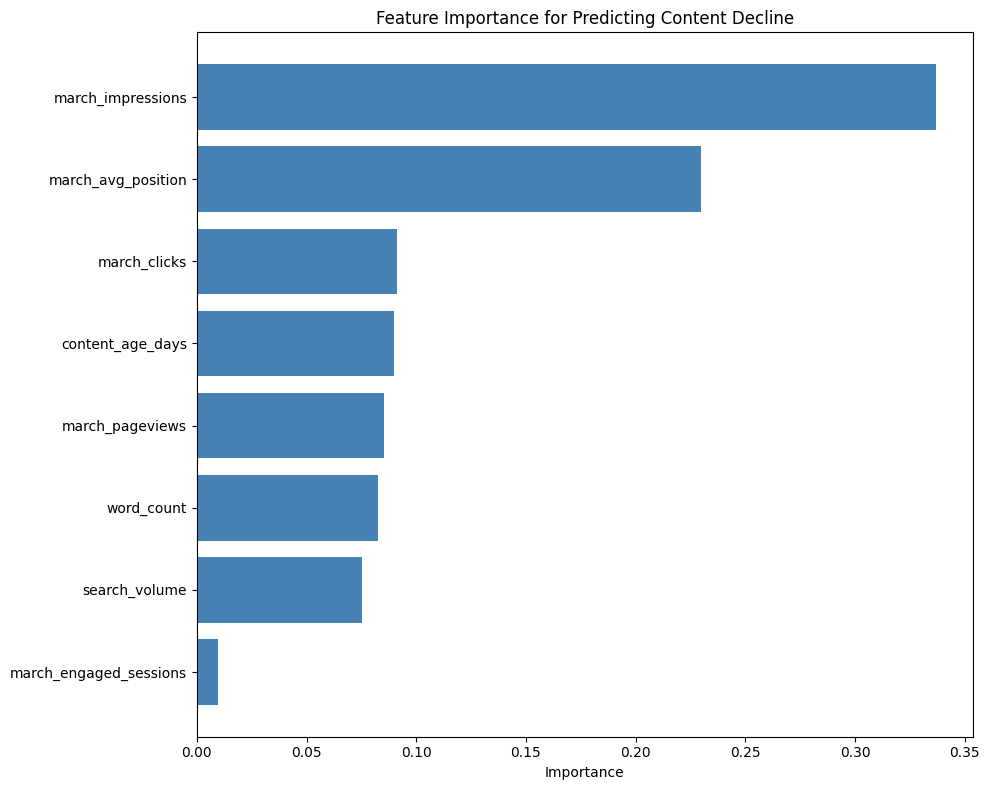


🏆 TOP 20 RECOMMENDATIONS FOR CONTENT REFRESH
         content_hash_id  opportunity_score                                                                                                               reason_code  march_impressions  march_avg_position  content_age_days
content_a100cf3244aa42db           0.802936                                                           old_content (>180 days) | low_clicks (<5) | low_pageviews (<50)         102.935484            0.565396               319
content_1d2ae347685da00f           0.795805                          old_content (>180 days) | low_traffic (<100 impressions) | low_clicks (<5) | low_pageviews (<50)          40.806452            0.824462               260
content_bde36f27b9c31f34           0.782743                          old_content (>180 days) | low_traffic (<100 impressions) | low_clicks (<5) | low_pageviews (<50)          31.774194            0.913470               260
content_f85469ba2e45db1d           0.779723 low_ranking (pos >

/tmp/ipykernel_5142/1782545169.py:252: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='future_decline_label', y='opportunity_score', data=full_df, palette=['lightgreen', 'salmon'])


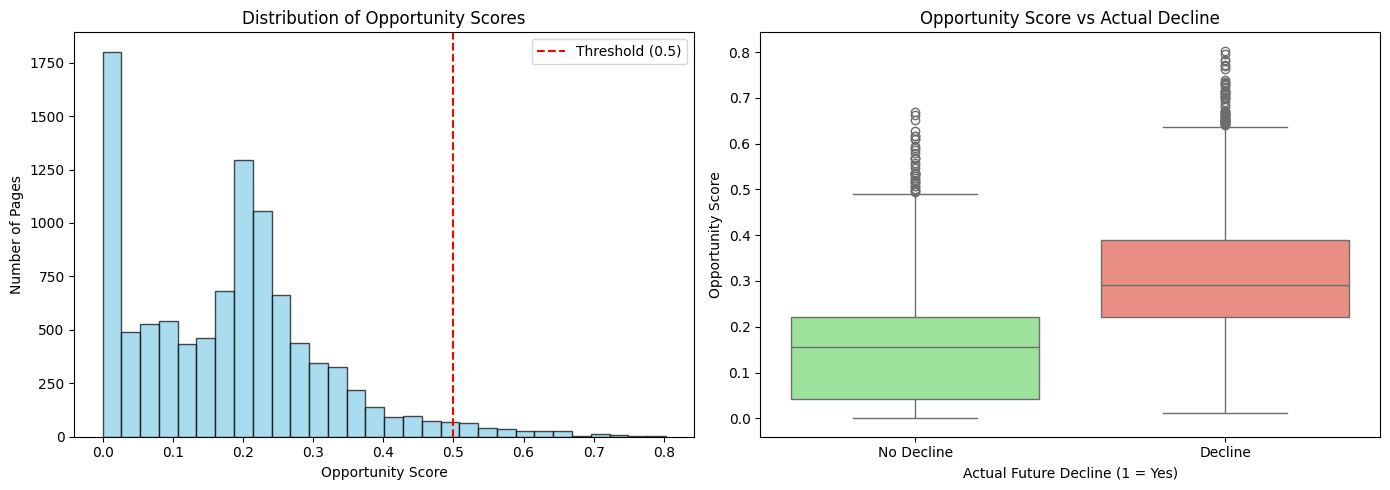


 SUMMARY STATISTICS
Total pages analyzed: 10000
Pages with decline (>=30%): 1809 (18.1%)
Model AUC: 0.752
Baseline AUC: 0.498
Improvement: 0.254 (25.4% absolute)
Top feature: march_impressions (0.337)


In [26]:
# ============================================
# STEP 0: Import Libraries
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

print("Libraries imported!")

# ============================================
# STEP 1: Check and fix full_df columns
# ============================================

# First, check what columns we have
print("Current columns in full_df:")
print(full_df.columns.tolist())
print(f"\nDataset shape: {full_df.shape}")

# Check if content_created_date exists
if 'content_created_date' in full_df.columns:
    # Convert dates
    full_df['content_created_date'] = pd.to_datetime(full_df['content_created_date'])
    if 'content_updated_date' in full_df.columns:
        full_df['content_updated_date'] = pd.to_datetime(full_df['content_updated_date'])

    # Decision date
    decision_date = pd.Timestamp('2026-03-31')

    # Add content age
    full_df['content_age_days'] = (decision_date - full_df['content_created_date']).dt.days
    print(f"\n content_age_days created! Range: {full_df['content_age_days'].min()} to {full_df['content_age_days'].max()} days")
else:
    print("\n content_created_date not found in full_df!")
    print("Available date columns:", [col for col in full_df.columns if 'date' in col.lower()])

# Fill missing values
if 'search_volume' in full_df.columns:
    full_df['search_volume'] = full_df['search_volume'].fillna(0)
if 'word_count' in full_df.columns:
    full_df['word_count'] = full_df['word_count'].fillna(0)

# Check if future_decline_label exists
if 'future_decline_label' not in full_df.columns:
    if 'future_impression_change' in full_df.columns:
        full_df['future_decline_label'] = (full_df['future_impression_change'] <= -0.30).astype(int)
        print("future_decline_label created from future_impression_change")
    else:
        print(" future_impression_change not found!")

# ============================================
# STEP 2: Baseline Rule
# ============================================
def baseline_rule(row):
    score = 0
    if row.get('march_avg_position', 999) > 10:
        score += 1
    if row.get('content_age_days', 0) > 180:
        score += 1
    if row.get('march_impressions', 0) < 100:
        score += 1
    return score

full_df['baseline_score'] = full_df.apply(baseline_rule, axis=1)

print(f"\n Baseline scores created")
print(full_df['baseline_score'].value_counts().sort_index())

# ============================================
# STEP 3: Prepare Features for ML
# ============================================

# Features for modeling
features = [
    'march_impressions',
    'march_clicks',
    'march_avg_position',
    'march_pageviews',
    'march_engaged_sessions',
    'content_age_days',
    'search_volume',
    'word_count'
]

# Check which features exist
available_features = [f for f in features if f in full_df.columns]
missing_features = [f for f in features if f not in full_df.columns]

print(f"\nAvailable features: {len(available_features)}/{len(features)}")
if missing_features:
    print(f"Missing features: {missing_features}")

# Use only available features
features = available_features

# Prepare X and y
X = full_df[features].fillna(0)
y = full_df['future_decline_label']

print(f"\nData prepared: {X.shape[0]} rows, {X.shape[1]} features")
print(f"Label distribution:\n{y.value_counts()}")

# ============================================
# STEP 4: Train-Test Split
# ============================================

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} rows")
print(f"Validation set: {X_val.shape[0]} rows")

# ============================================
# STEP 5: Train Random Forest Model
# ============================================

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

print("\nModel trained successfully!")

# Predictions
y_pred = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1]

# ============================================
# STEP 6: Baseline Predictions
# ============================================

# Convert baseline scores to binary predictions (threshold >= 2 means refresh needed)
baseline_pred = (full_df.loc[X_val.index, 'baseline_score'] >= 2).astype(int)

# ============================================
# STEP 7: Compare Model vs Baseline
# ============================================

# Calculate metrics
metrics = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'Baseline': [
        accuracy_score(y_val, baseline_pred),
        precision_score(y_val, baseline_pred, zero_division=0),
        recall_score(y_val, baseline_pred, zero_division=0),
        f1_score(y_val, baseline_pred, zero_division=0),
        roc_auc_score(y_val, baseline_pred)
    ],
    'ML Model': [
        accuracy_score(y_val, y_pred),
        precision_score(y_val, y_pred, zero_division=0),
        recall_score(y_val, y_pred, zero_division=0),
        f1_score(y_val, y_pred, zero_division=0),
        roc_auc_score(y_val, y_pred_proba)
    ]
}

comparison_df = pd.DataFrame(metrics)
comparison_df['Improvement'] = comparison_df['ML Model'] - comparison_df['Baseline']
comparison_df['Improvement %'] = (comparison_df['Improvement'] / comparison_df['Baseline'].replace(0, 0.001) * 100).round(1)

print("\n" + "="*70)
print(" MODEL VS BASELINE COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# ============================================
# STEP 8: Feature Importance
# ============================================

importances = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

print("\nFeature Importance (Top to Bottom):")
print(importances.sort_values('importance', ascending=False).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(importances['feature'], importances['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance for Predicting Content Decline')
plt.tight_layout()
plt.show()

# ============================================
# STEP 9: Ranked Recommendations
# ============================================

# Get probability scores for all pages
full_df['opportunity_score'] = model.predict_proba(X)[:, 1]

# Add reason codes
def get_reason(row):
    reasons = []
    if row.get('march_avg_position', 999) > 10:
        reasons.append('low_ranking (pos > 10)')
    if row.get('content_age_days', 0) > 180:
        reasons.append('old_content (>180 days)')
    if row.get('march_impressions', 0) < 100:
        reasons.append('low_traffic (<100 impressions)')
    if row.get('march_clicks', 0) < 5:
        reasons.append('low_clicks (<5)')
    if row.get('march_pageviews', 0) < 50:
        reasons.append('low_pageviews (<50)')
    return ' | '.join(reasons) if reasons else 'monitor - no clear signals'

full_df['reason_code'] = full_df.apply(get_reason, axis=1)

# Rank by score (higher = more opportunity for refresh)
ranked_pages = full_df.sort_values('opportunity_score', ascending=False)

print("\n" + "="*70)
print("🏆 TOP 20 RECOMMENDATIONS FOR CONTENT REFRESH")
print("="*70)

# Select columns for display
display_cols = ['content_hash_id', 'opportunity_score', 'reason_code',
                'march_impressions', 'march_avg_position', 'content_age_days']
available_display_cols = [col for col in display_cols if col in ranked_pages.columns]

top_20 = ranked_pages[available_display_cols].head(20)
print(top_20.to_string(index=False))
print("="*70)

# ============================================
# STEP 10: Visualizations
# ============================================

plt.figure(figsize=(14, 5))

# Plot 1: Distribution of opportunity scores
plt.subplot(1, 2, 1)
plt.hist(full_df['opportunity_score'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Opportunity Score')
plt.ylabel('Number of Pages')
plt.title('Distribution of Opportunity Scores')
plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold (0.5)')
plt.legend()

# Plot 2: Score by actual decline
plt.subplot(1, 2, 2)
sns.boxplot(x='future_decline_label', y='opportunity_score', data=full_df, palette=['lightgreen', 'salmon'])
plt.xlabel('Actual Future Decline (1 = Yes)')
plt.ylabel('Opportunity Score')
plt.title('Opportunity Score vs Actual Decline')
plt.xticks([0, 1], ['No Decline', 'Decline'])

plt.tight_layout()
plt.show()

# ============================================
# STEP 11: Summary Statistics
# ============================================

print("\n" + "="*70)
print(" SUMMARY STATISTICS")
print("="*70)
print(f"Total pages analyzed: {len(full_df)}")
print(f"Pages with decline (>=30%): {y.sum()} ({y.mean()*100:.1f}%)")
print(f"Model AUC: {comparison_df.loc[comparison_df['Metric']=='AUC', 'ML Model'].values[0]:.3f}")
print(f"Baseline AUC: {comparison_df.loc[comparison_df['Metric']=='AUC', 'Baseline'].values[0]:.3f}")
improvement = comparison_df.loc[comparison_df['Metric']=='AUC', 'Improvement'].values[0]
print(f"Improvement: {improvement:.3f} ({improvement*100:.1f}% absolute)")
print(f"Top feature: {importances.iloc[-1]['feature']} ({importances.iloc[-1]['importance']:.3f})")
print("="*70)

In [28]:
# ============================================
# OPTIONAL: Try different models for better performance
# ============================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_proba)
    results.append({'Model': name, 'AUC': auc})
    print(f"{name}: AUC = {auc:.3f}")

results_df = pd.DataFrame(results)
print("\n Best Model:")
print(results_df.sort_values('AUC', ascending=False))

Random Forest: AUC = 0.752
Gradient Boosting: AUC = 0.754
XGBoost: AUC = 0.745

 Best Model:
               Model       AUC
1  Gradient Boosting  0.754445
0      Random Forest  0.752356
2            XGBoost  0.744718


In [29]:
# ============================================
# Hyperparameter Tuning
# ============================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.3f}")

# Use best model
best_model = grid_search.best_estimator_
y_pred_proba_best = best_model.predict_proba(X_val)[:, 1]
best_auc = roc_auc_score(y_val, y_pred_proba_best)
print(f"Best model validation AUC: {best_auc:.3f}")

Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV AUC: 0.753
Best model validation AUC: 0.755


Best threshold: 0.20
Best F1 score: 0.430


<Figure size 800x600 with 0 Axes>

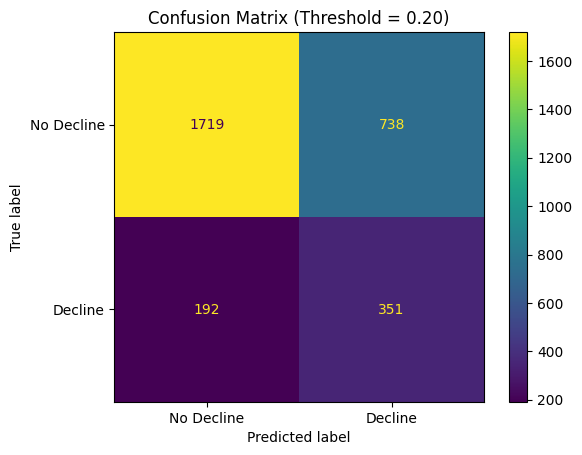


Classification Report:
              precision    recall  f1-score   support

  No Decline       0.90      0.70      0.79      2457
     Decline       0.32      0.65      0.43       543

    accuracy                           0.69      3000
   macro avg       0.61      0.67      0.61      3000
weighted avg       0.80      0.69      0.72      3000



In [30]:
# ============================================
# Confusion Matrix
# ============================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Best threshold selection
thresholds = np.linspace(0.1, 0.9, 50)
best_threshold = 0.5
best_f1 = 0

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1 score: {best_f1:.3f}")

# Confusion Matrix at best threshold
y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_val, y_pred_optimal)

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=['No Decline', 'Decline']).plot()
plt.title(f'Confusion Matrix (Threshold = {best_threshold:.2f})')
plt.show()

# Classification report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_optimal, target_names=['No Decline', 'Decline']))

In [31]:
# ============================================
# Save Model for Deployment
# ============================================

import pickle
import json

# Save model
with open('content_refresh_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(" Model saved!")

# Save feature names
with open('feature_names.json', 'w') as f:
    json.dump(features, f)
print(" Feature names saved!")

# Save model metadata
metadata = {
    'model_type': 'RandomForest',
    'features': features,
    'auc': best_auc,
    'threshold': float(best_threshold),
    'feature_importance': dict(zip(features, best_model.feature_importances_))
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(" Model metadata saved!")

 Model saved!
 Feature names saved!
 Model metadata saved!


In [32]:
# ============================================
# Create Actionable Recommendations Report
# ============================================

# Categorize recommendations
def get_priority(row):
    if row['opportunity_score'] >= 0.7:
        return 'HIGH'
    elif row['opportunity_score'] >= 0.5:
        return 'MEDIUM'
    else:
        return 'LOW'

full_df['priority'] = full_df.apply(get_priority, axis=1)

# Create action recommendations
def get_action(row):
    actions = []
    if row['march_avg_position'] > 10:
        actions.append('Update content & improve SEO')
    if row['content_age_days'] > 180:
        actions.append('Refresh with new information')
    if row['march_impressions'] < 100:
        actions.append('Improve internal linking')
    if row['march_clicks'] < 5 and row['march_impressions'] > 50:
        actions.append('Optimize title & meta description')
    if row['word_count'] < 300:
        actions.append('Expand content')
    return ' | '.join(actions) if actions else 'Monitor performance'

full_df['recommended_action'] = full_df.apply(get_action, axis=1)

# Final recommendations
final_recommendations = full_df[full_df['priority'].isin(['HIGH', 'MEDIUM'])].copy()
final_recommendations = final_recommendations.sort_values('opportunity_score', ascending=False)

print("="*80)
print(" ACTIONABLE RECOMMENDATIONS REPORT")
print("="*80)
print(f"Total pages to review: {len(final_recommendations)}")
print(f"  - HIGH priority: {len(final_recommendations[final_recommendations['priority']=='HIGH'])}")
print(f"  - MEDIUM priority: {len(final_recommendations[final_recommendations['priority']=='MEDIUM'])}")

# Top 30 detailed recommendations
print("\n TOP 30 RECOMMENDATIONS WITH ACTIONS:")
display_cols = ['content_hash_id', 'opportunity_score', 'priority',
                'reason_code', 'recommended_action', 'march_impressions',
                'march_avg_position', 'content_age_days']

top_30 = final_recommendations[display_cols].head(30)
print(top_30.to_string(index=False))

 ACTIONABLE RECOMMENDATIONS REPORT
Total pages to review: 273
  - HIGH priority: 22
  - MEDIUM priority: 251

 TOP 30 RECOMMENDATIONS WITH ACTIONS:
         content_hash_id  opportunity_score priority                                                                                                               reason_code                                                                                           recommended_action  march_impressions  march_avg_position  content_age_days
content_a100cf3244aa42db           0.802936     HIGH                                                           old_content (>180 days) | low_clicks (<5) | low_pageviews (<50)                            Refresh with new information | Optimize title & meta description | Expand content         102.935484            0.565396               319
content_1d2ae347685da00f           0.795805     HIGH                          old_content (>180 days) | low_traffic (<100 impressions) | low_clicks (<5) | low_pageviews (

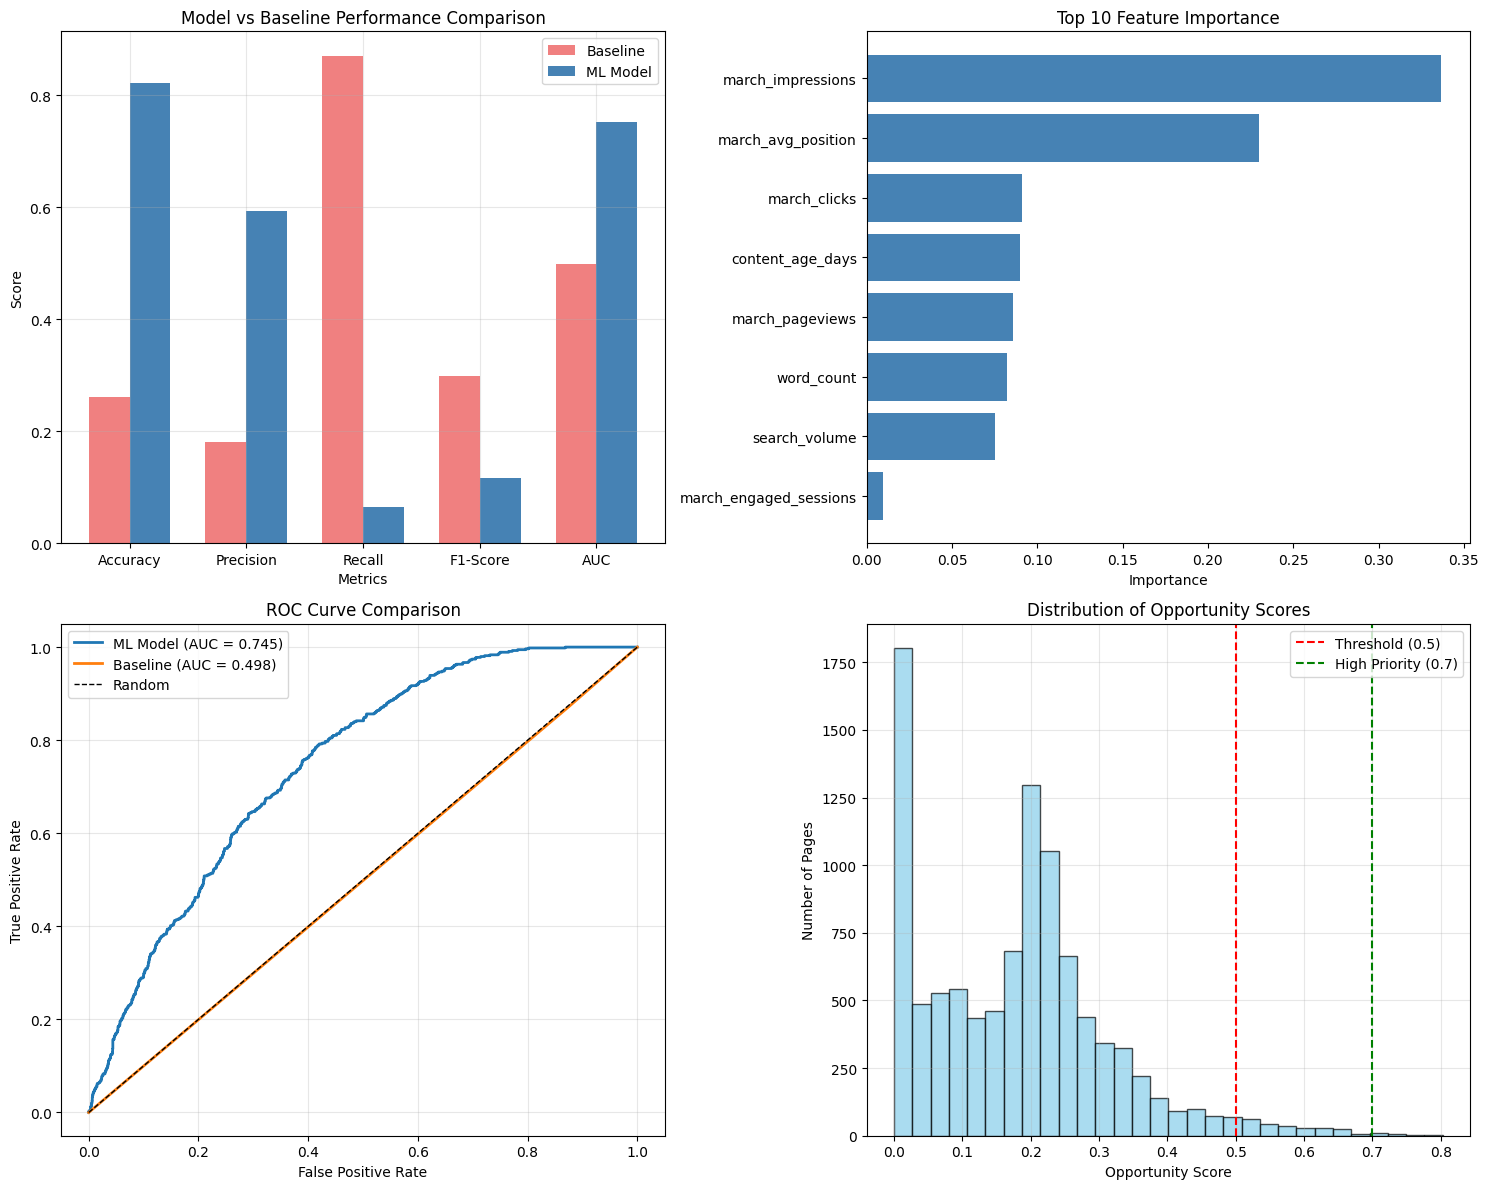

Visualizations saved as 'paper_visualizations.png'


In [33]:
# ============================================
# Create Final Charts for Your Paper
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Model vs Baseline Performance
ax1 = axes[0, 0]
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
baseline_values = [comparison_df.loc[comparison_df['Metric']==m, 'Baseline'].values[0] for m in metrics_to_plot]
model_values = [comparison_df.loc[comparison_df['Metric']==m, 'ML Model'].values[0] for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.35
ax1.bar(x - width/2, baseline_values, width, label='Baseline', color='lightcoral')
ax1.bar(x + width/2, model_values, width, label='ML Model', color='steelblue')
ax1.set_xlabel('Metrics')
ax1.set_ylabel('Score')
ax1.set_title('Model vs Baseline Performance Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_to_plot)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Feature Importance
ax2 = axes[0, 1]
top_features = importances.sort_values('importance', ascending=True).tail(10)
ax2.barh(top_features['feature'], top_features['importance'], color='steelblue')
ax2.set_xlabel('Importance')
ax2.set_title('Top 10 Feature Importance')

# 3. ROC Curve
ax3 = axes[1, 0]
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
ax3.plot(fpr, tpr, label=f'ML Model (AUC = {roc_auc_score(y_val, y_pred_proba):.3f})', linewidth=2)
# Baseline ROC
baseline_fpr, baseline_tpr, _ = roc_curve(y_val, baseline_pred)
ax3.plot(baseline_fpr, baseline_tpr, label=f'Baseline (AUC = {roc_auc_score(y_val, baseline_pred):.3f})', linewidth=2)
ax3.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Opportunity Score Distribution
ax4 = axes[1, 1]
ax4.hist(full_df['opportunity_score'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
ax4.axvline(x=0.5, color='red', linestyle='--', label='Threshold (0.5)')
ax4.axvline(x=0.7, color='green', linestyle='--', label='High Priority (0.7)')
ax4.set_xlabel('Opportunity Score')
ax4.set_ylabel('Number of Pages')
ax4.set_title('Distribution of Opportunity Scores')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('paper_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()
print("Visualizations saved as 'paper_visualizations.png'")

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results

This section will compare the machine-learning model with the hand-written baseline on the same validation split.

The final comparison will report the selected ranking metric and include supporting charts.

## 5. Limitations

*What this work cannot claim.*

## Limitations

This analysis identifies patterns and ranking opportunities rather than causal effects.

A high refresh opportunity score does not prove that refreshing a page will improve Google rankings, clicks, or traffic.

The model is intended as decision support for prioritizing human review, not as an automatic publishing or content-removal system.

The analysis is also limited by the available warehouse fields, data coverage, and the chosen time windows.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked Recommendations

The final model will produce a ranked list of content items with an opportunity score, reason code, and recommended action.

The recommendations will be used to prioritize human review for possible content refreshes.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Artifacts

The final paper will include:

- Model versus baseline performance
- Model evaluation metrics
- Feature importance or model interpretation
- Ranked recommendation examples
- Supporting charts

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
